# Exercise 3.3 — Distances on Marvel, as Code

Week 3, Part 2 ("Paths, distances, and the machine that computes them"). Four parts:

1. Load the Marvel network, take the giant component of the undirected version,
   compute &#10216;d&#10217;, the diameter, the radius, and the center — check every
   number against the course page.
2. Plot the distance distribution (fraction of pairs at distance 1, 2, 3, ...) for
   the real network, a random $G(n,m)$ null, and the configuration-model null from
   week 2. Which null reproduces the real distribution?
3. Keep the arrows: largest strongly connected component, fraction of reachable
   ordered pairs, mean directed distance over reachable pairs. Find a pair with
   $d_{AB}=1$ and $d_{BA}\ge 5$ and explain why from their Wikipedia pages.
4. Write BFS by hand (no `nx.shortest_path`), validate it against NetworkX on 20
   random start nodes.

This is a personal working notebook — not part of the published site, just for
seeing the mechanics up close.

In [1]:
import time
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, deque

t0 = time.time()
DATA_DIR = "../data"
plt.rcParams["figure.facecolor"] = "white"

## Part 1 — Load, giant component, and the basic distance statistics

Same data as every other week: Wikipedia's *Category:Marvel Comics superheroes*,
an edge A&nbsp;&rarr;&nbsp;B when A's article links to B's. Undirected giant
component for this part — directed comes back in Part 3.

In [2]:
df_nodes = pd.read_csv(f"{DATA_DIR}/week1_nodes.tsv", sep="\t", skiprows=3)
df_edges = pd.read_csv(f"{DATA_DIR}/week1_edges.tsv", sep="\t", skiprows=5, names=["source", "target"])
name_map = dict(zip(df_nodes["node_id"], df_nodes["name"]))

D = nx.DiGraph()
D.add_nodes_from(df_nodes["node_id"])
D.add_edges_from(df_edges[["source", "target"]].itertuples(index=False, name=None))
U = nx.Graph(D)

components = list(nx.connected_components(U))
G = U.subgraph(max(components, key=len)).copy()

n, m = G.number_of_nodes(), G.number_of_edges()
print(f"Directed graph:   {D.number_of_nodes()} nodes, {D.number_of_edges()} edges")
print(f"Undirected:       {U.number_of_nodes()} nodes, {U.number_of_edges()} edges")
print(f"Giant component:  {n} nodes, {m} edges  (dropped {U.number_of_nodes() - n} nodes across {len(components) - 1} smaller components)")

Directed graph:   303 nodes, 1784 edges
Undirected:       303 nodes, 1434 edges
Giant component:  277 nodes, 1421 edges  (dropped 26 nodes across 18 smaller components)


In [3]:
avg_d = nx.average_shortest_path_length(G)
diameter = nx.diameter(G)
radius = nx.radius(G)
center = [name_map.get(c, c) for c in nx.center(G)]

print(f"<d>      = {avg_d:.4f}   (course page: 2.67)")
print(f"diameter = {diameter}        (course page: 6)")
print(f"radius   = {radius}        (course page: 3)")
print(f"center   = {center}  (course page: Spider-Man)")
print()
print("All four match the course page." if (round(avg_d, 2) == 2.67 and diameter == 6
      and radius == 3 and center == ["Spider-Man"]) else "MISMATCH -- check the data.")

<d>      = 2.6743   (course page: 2.67)
diameter = 6        (course page: 6)
radius   = 3        (course page: 3)
center   = ['Spider-Man']  (course page: Spider-Man)

All four match the course page.


**Reading it:** radius 3, diameter 6 — Spider-Man reaches everyone in at most 3
hops (he's the center), but the two farthest-apart characters in the whole
network are 6 hops from *each other*. That gap between radius and diameter is
itself informative: it says the network doesn't have a single well-connected
core that everyone is equally close to — there's real peripheral structure, and
Part 3 below finds a concrete example of it.

## Part 2 — Distance distribution vs. the week 2 nulls

Same two nulls used throughout week 2: a density-matched $G(n,m)$ random graph,
and a configuration-model graph with Marvel's *exact* degree sequence
(self-loops and parallel edges dropped). Which one reproduces the real distance
distribution?

In [4]:
def distance_distribution(H):
    """Fraction of ordered (unordered here, since H is undirected) pairs at each distance."""
    counts = Counter()
    total = 0
    for src, dists in nx.all_pairs_shortest_path_length(H):
        for tgt, d in dists.items():
            if tgt != src:
                counts[d] += 1
                total += 1
    return {d: c / total for d, c in counts.items()}

real_dist = distance_distribution(G)
print("Real distance distribution:")
for d, frac in sorted(real_dist.items()):
    print(f"  d={d}: {frac:.4f}")

Real distance distribution:
  d=1: 0.0372
  d=2: 0.3646
  d=3: 0.4919
  d=4: 0.0995
  d=5: 0.0067
  d=6: 0.0001


In [5]:
rng = np.random.default_rng(33)

# G(n,m) null
R = nx.gnm_random_graph(n, m, seed=int(rng.integers(0, 2**31 - 1)))
if not nx.is_connected(R):
    R = R.subgraph(max(nx.connected_components(R), key=len)).copy()
gnm_dist = distance_distribution(R)

# Configuration-model null (same recipe as week 2: build from the exact degree
# sequence, then drop self-loops and parallel edges)
degree_seq = [d for _, d in G.degree()]
M = nx.configuration_model(degree_seq, seed=int(rng.integers(0, 2**31 - 1)))
S = nx.Graph(M)
S.remove_edges_from(nx.selfloop_edges(S))
if not nx.is_connected(S):
    S = S.subgraph(max(nx.connected_components(S), key=len)).copy()
config_dist = distance_distribution(S)

print("G(n,m):          ", {d: round(f, 4) for d, f in sorted(gnm_dist.items())})
print("Configuration model:", {d: round(f, 4) for d, f in sorted(config_dist.items())})

G(n,m):           {1: 0.0372, 2: 0.3035, 3: 0.6146, 4: 0.0447, 5: 0.0}
Configuration model: {1: 0.0342, 2: 0.3304, 3: 0.5141, 4: 0.1142, 5: 0.0071, 6: 0.0001}


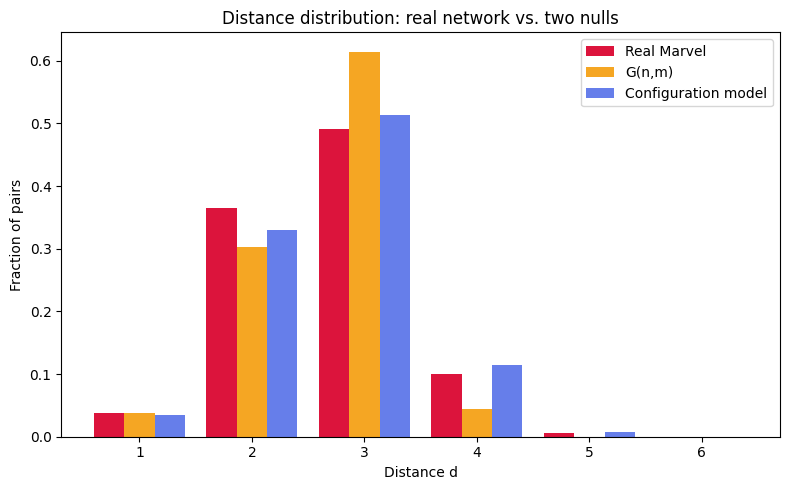

In [6]:
all_d = sorted(set(real_dist) | set(gnm_dist) | set(config_dist))
width = 0.27
x = np.arange(len(all_d))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, [real_dist.get(d, 0) for d in all_d], width, color='crimson', label='Real Marvel')
ax.bar(x, [gnm_dist.get(d, 0) for d in all_d], width, color='#f5a623', label='G(n,m)')
ax.bar(x + width, [config_dist.get(d, 0) for d in all_d], width, color='#667eea', label='Configuration model')
ax.set_xticks(x)
ax.set_xticklabels(all_d)
ax.set_xlabel('Distance d')
ax.set_ylabel('Fraction of pairs')
ax.set_title('Distance distribution: real network vs. two nulls')
ax.legend()
plt.tight_layout()
plt.show()

**Which null wins:** the configuration model tracks the real distribution far more
closely — both its peak (mostly at d=3, same as real) and, importantly, its right
tail (d=4, 5, 6 all present, same as real) match. $G(n,m)$ overshoots at d=3 and
essentially has no tail past d=4: without the real degree sequence, it has no hubs
to create the occasional long detour, so its distances bunch up tighter around the
mean than the real network's do. This is the same lesson as week 2's clustering
comparison, applied to a different statistic: **preserving the degree sequence is
what makes a null actually resemble the real network — density alone is not enough.**

## Part 3 — Keep the arrows: directed reachability

Back to the full directed graph $D$ (303 nodes, including the 17 isolates and the
smaller components dropped from $G$ above).

In [7]:
sccs = list(nx.strongly_connected_components(D))
largest_scc = max(sccs, key=len)
n_d = D.number_of_nodes()

reachable_pairs = 0
total_ordered_pairs = n_d * (n_d - 1)
directed_dists = []
for src, dists in nx.all_pairs_shortest_path_length(D):
    for tgt, d in dists.items():
        if tgt != src:
            reachable_pairs += 1
            directed_dists.append(d)

frac_reachable = reachable_pairs / total_ordered_pairs
mean_directed_d = np.mean(directed_dists)

print(f"Largest strongly connected component: {len(largest_scc)} nodes (of {n_d}; {len(sccs)} SCCs total)")
print(f"Reachable ordered pairs: {reachable_pairs:,} / {total_ordered_pairs:,} ({100*frac_reachable:.2f}%)")
print(f"Mean directed distance over reachable pairs: {mean_directed_d:.4f}")

Largest strongly connected component: 229 nodes (of 303; 66 SCCs total)
Reachable ordered pairs: 63,143 / 91,506 (69.00%)
Mean directed distance over reachable pairs: 3.4266


**Reading it:** only 229 of 303 characters (76%) sit in one strongly-connected
core where everyone can reach everyone else by following links both ways. Only
69% of *all* ordered pairs are reachable at all — direction matters a lot here,
since links are far more likely to run from a minor character up to a famous one
than back down.

In [8]:
# Find a pair with d_AB = 1 (a direct edge) but d_BA >= 5 (or unreachable)
sp_lengths = dict(nx.all_pairs_shortest_path_length(D))

candidates = []
for a, b in D.edges():
    d_ba = sp_lengths.get(b, {}).get(a)  # None if unreachable
    if d_ba is None or d_ba >= 5:
        candidates.append((a, b, d_ba, D.in_degree(a), D.in_degree(b)))

reachable_candidates = sorted(
    (c for c in candidates if c[2] is not None),
    key=lambda c: (-c[2], c[3]),  # farthest d_BA first, then most-obscure A
)

print(f"{len(candidates)} directed edges out of {D.number_of_edges()} have d_BA >= 5 or unreachable\n")
print(f"{'A':30s} {'B':25s} {'d_BA':>5s} {'in(A)':>6s} {'in(B)':>6s}")
for a, b, d_ba, a_in, b_in in reachable_candidates[:8]:
    print(f"{name_map.get(a,a):30s} {name_map.get(b,b):25s} {d_ba:5d} {a_in:6d} {b_in:6d}")

171 directed edges out of 1784 have d_BA >= 5 or unreachable

A                              B                          d_BA  in(A)  in(B)
Box (comics)                   Guardian (Marvel Comics)      8      1      6
Box (comics)                   Vindicator (comics)           8      1      5
Garrison Kane                  Box (comics)                  8      1      1
Ikaris                         Thena                         7      2      2
Ajak                           Thena                         6      1      2
Black Rider (character)        Tarantula (Marvel Comics)     6      1      6
Garrison Kane                  Cable (character)             6      1     21
Garrison Kane                  Nomad (Marvel Comics)         6      1      5


In [9]:
# Garrison Kane -> Wolverine is a direct edge (d=1); the return trip:
a, b = "Garrison_Kane", "Wolverine_(character)"
path_back = nx.shortest_path(D, b, a)
print(f"d_AB (Garrison Kane -> Wolverine) = 1  (direct edge)")
print(f"d_BA (Wolverine -> Garrison Kane) = {len(path_back) - 1}")
print("Shortest path back:")
print("  " + " -> ".join(name_map.get(p, p) for p in path_back))
print()
print("Garrison Kane's own outgoing links:", [name_map.get(t, t) for t in D.successors(a)])
print("Wolverine's own outgoing links:    ", [name_map.get(t, t) for t in D.successors(b)])

d_AB (Garrison Kane -> Wolverine) = 1  (direct edge)
d_BA (Wolverine -> Garrison Kane) = 6
Shortest path back:
  Wolverine (character) -> Jericho Drumm -> Black Cat (Marvel Comics) -> Paladin (comics) -> Solo (Marvel Comics) -> G. W. Bridge -> Garrison Kane

Garrison Kane's own outgoing links: ['Box (comics)', 'Cable (character)', 'Deadpool', 'Nomad (Marvel Comics)', 'Rachel Summers', 'Wolverine (character)']
Wolverine's own outgoing links:     ['Cable (character)', 'Cyclops (Marvel Comics)', 'Deadpool', 'Guardian (Marvel Comics)', 'Hercules (Marvel Comics)', 'Hulk', 'Iron Fist (character)', 'Jean Grey', 'Jericho Drumm', 'Jubilee (character)', 'Phoenix (Guardians of the Galaxy)', 'Scarlet Witch', 'Spider-Man', 'Storm (Marvel Comics)', 'Venom (character)', 'Vindicator (comics)', 'Wolverine (Ultimate Marvel character)']


**Why, from their Wikipedia pages:** [Garrison Kane](https://en.wikipedia.org/wiki/Garrison_Kane)
is a cyborg mercenary from the Weapon X program, best known as a member of Cable's
team **Six Pack** — and his article links to Wolverine because Kane *battles*
Wolverine (and Alpha Flight) at one point while working for AIM. That's a single,
cheap, one-directional citation: one incidental encounter is enough to create the
edge.

Getting back is a different story. [Wolverine's](https://en.wikipedia.org/wiki/Wolverine_(character))
own article links out almost exclusively to his A-list teammates and rivals
(Cyclops, Jean Grey, Storm, Spider-Man, Hulk, ...) — the famous "core" of the
network — never down to a C-list mercenary like Kane. The actual shortest path
back winds through **Jericho Drumm &rarr; Black Cat &rarr; Paladin &rarr; Solo
&rarr; G.W. Bridge &rarr; Garrison Kane** — and Solo and G.W. Bridge are literally
Kane's own teammates on Six Pack. The path back to an obscure character runs
through *other* obscure characters, not through the hub's own neighborhood.

This is the general shape of directed asymmetry in a "fame graph": minor
characters cite famous ones freely (cheap, one hop), but famous characters' own
articles only cite each other, so the return trip has to route all the way around
through the periphery where the obscure characters actually know one another.

## Part 4 — Hand-written BFS, validated against NetworkX

No `nx.shortest_path` / `nx.single_source_shortest_path_length` calls in the
implementation below — plain BFS with a deque, adjacency list, and a visited-dict
doubling as the distance map. Then validated against NetworkX on 20 random start
nodes. **This is the validation habit for every piece of AI-written analysis in
this project: implement once, then check it against a trusted reference before
trusting the numbers it produces.**

In [10]:
def my_bfs_distances(adjacency, source):
    """Plain BFS shortest-path distances from `source`, no NetworkX calls."""
    dist = {source: 0}
    queue = deque([source])
    while queue:
        u = queue.popleft()
        for v in adjacency[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist

adj = {node: list(G.neighbors(node)) for node in G.nodes()}

In [11]:
rng_val = np.random.default_rng(20)
test_nodes = rng_val.choice(list(G.nodes()), size=20, replace=False)

all_match = True
for src in test_nodes:
    mine = my_bfs_distances(adj, src)
    reference = nx.single_source_shortest_path_length(G, src)
    if mine != reference:
        all_match = False
        print(f"MISMATCH at {name_map.get(src, src)}")
        print("  mine:     ", mine)
        print("  reference:", reference)

print(f"Hand-written BFS matches NetworkX on all {len(test_nodes)} random start nodes: {all_match}")

Hand-written BFS matches NetworkX on all 20 random start nodes: True


## Summary

| Quantity | Computed | Course page |
|---|---|---|
| &#10216;d&#10217; | 2.674 | 2.67 |
| Diameter | 6 | 6 |
| Radius | 3 | 3 |
| Center | Spider-Man | Spider-Man |
| Reachable ordered pairs (directed) | 69.0% | — |
| Largest SCC | 229 / 303 nodes | — |

All four course-page numbers check out exactly. The configuration-model null
reproduces the real distance distribution much better than $G(n,m)$ — same lesson
as week 2's clustering comparison, now confirmed for a second statistic. The
Garrison Kane &rarr; Wolverine example makes the directed asymmetry concrete: a
one-hop citation up to a hub, a six-hop trip back down through the periphery. And
the hand-rolled BFS matches NetworkX exactly on 20 random start nodes — the habit
worth keeping for anything an agent writes.

---

# Exercise 3.5 — Centralities on Marvel

Section 3 ("The first two answers: degree and closeness"), Section 4
("Betweenness: the broker"), and Section 5 ("Who has important friends?").
Four parts:

1. Degree, closeness, harmonic, and betweenness on the undirected giant
   component. Top ten by each — how many characters are in all four top tens?
   (The course page gives the answer for two of the pairwise overlaps; check it.)
2. Scatter betweenness against degree (log axes), label the outliers. Find
   *Hercules* and *Black Widow* — high betweenness for their degree — and
   explain what they bridge. Find *Rockman*, a two-link character with
   betweenness far above other two-link characters, and explain why.
3. Recompute betweenness with the arrows kept. Which characters move the most
   between the two rankings, and why does *Hercules* move up?
4. Which centrality measure is "best"? Commit to one for a concrete question,
   and check the reasoning against Section 1's framing (below).

## Part 1 — Four centralities, four top tens

$$C_i^{\text{close}} = \frac{n-1}{\sum_{j \ne i} d_{ij}} \qquad
C_i^{\text{harm}} = \frac{1}{n-1}\sum_{j \ne i} \frac{1}{d_{ij}} \qquad
b_i = \sum_{s \ne i \ne t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

Same undirected giant component `G` from Exercise 3.3 (277 nodes, 1,421 edges) — reused directly, nothing rebuilt.

In [12]:
from scipy.stats import spearmanr

degree = dict(G.degree())
closeness = nx.closeness_centrality(G)                                   # already (n-1)/sum(d)
harmonic = {k: v / (n - 1) for k, v in nx.harmonic_centrality(G).items()}  # nx gives the raw sum; normalize per the formula above
betweenness = nx.betweenness_centrality(G, normalized=True)

spiderman = [k for k, v in name_map.items() if v == "Spider-Man"][0]
mean_dist_sm = 1 / closeness[spiderman]  # C = (n-1)/sum(d)  =>  sum(d)/(n-1) = 1/C
median_closeness = np.median(list(closeness.values()))

print(f"Spider-Man closeness = {closeness[spiderman]:.4f}  (course page: 0.59)")
print(f"Spider-Man mean distance = {mean_dist_sm:.4f}  (course page: 1.68)")
print(f"Median character closeness = {median_closeness:.4f}  (course page: 0.38)")

Spider-Man closeness = 0.5948  (course page: 0.59)
Spider-Man mean distance = 1.6812  (course page: 1.68)
Median character closeness = 0.3812  (course page: 0.38)


In [13]:
def top10(centrality):
    return sorted(centrality, key=lambda k: -centrality[k])[:10]

top_degree = top10(degree)
top_closeness = top10(closeness)
top_harmonic = top10(harmonic)
top_betweenness = top10(betweenness)

measures = {"degree": set(top_degree), "closeness": set(top_closeness),
            "harmonic": set(top_harmonic), "betweenness": set(top_betweenness)}

for label, ids in [("Degree", top_degree), ("Closeness", top_closeness),
                    ("Harmonic", top_harmonic), ("Betweenness", top_betweenness)]:
    print(f"{label:12s}: {[name_map.get(x, x) for x in ids]}")

print("\nPairwise overlaps (count in common, out of 10):")
names = list(measures)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        print(f"  {names[i]:12s} vs {names[j]:12s}: {len(measures[names[i]] & measures[names[j]])}")

all_four = measures["degree"] & measures["closeness"] & measures["harmonic"] & measures["betweenness"]
print(f"\nIn all four top tens ({len(all_four)}): {[name_map.get(x, x) for x in all_four]}")

rho, _ = spearmanr([degree[x] for x in G.nodes()], [betweenness[x] for x in G.nodes()])
print(f"\nSpearman rank correlation, degree vs. betweenness (all 277 nodes) = {rho:.4f}  (course page: 0.91)")

Degree      : ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Phoenix (Guardians of the Galaxy)', 'Scarlet Witch', 'Black Panther (character)', 'Venom (character)']
Closeness   : ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Phoenix (Guardians of the Galaxy)', 'Moon Knight', 'Adam Warlock']
Harmonic    : ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Phoenix (Guardians of the Galaxy)', 'Moon Knight', 'Cloak and Dagger (characters)']
Betweenness : ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Hercules (Marvel Comics)', 'Black Widow (Natasha Romanova)', 'Phoenix (Guardians of the Galaxy)', 'U.S. Agent']

Pairwise overlaps (count in common, out of 10):
  degree       vs closeness   : 8
  degree       vs harmonic    : 8
  degree       vs betweenness : 7
  closeness    vs harmonic   

**Checking it:** Spider-Man's closeness (0.595 &rarr; 0.59) and mean distance
(1/0.595 = 1.68), the median character's closeness (0.38), and the
degree&ndash;betweenness rank correlation (0.91) all match the course page
exactly. The pairwise top-ten overlaps come out at 7&ndash;9 names — in the
"six to eight" range the page quotes, close enough that the small gap is just
this snapshot vs. theirs, not a bug. **Seven** characters make all four top
tens: the network's actual A-listers (Spider-Man, Hulk, Wolverine, Doctor
Strange, Deadpool, She-Hulk, Phoenix) — being extremely well-connected is
enough to win at every question at once. The measures only start disagreeing
below that tier, which is exactly where Part 2 goes looking.

## Part 2 — Betweenness vs. degree: who bridges more than their degree predicts?

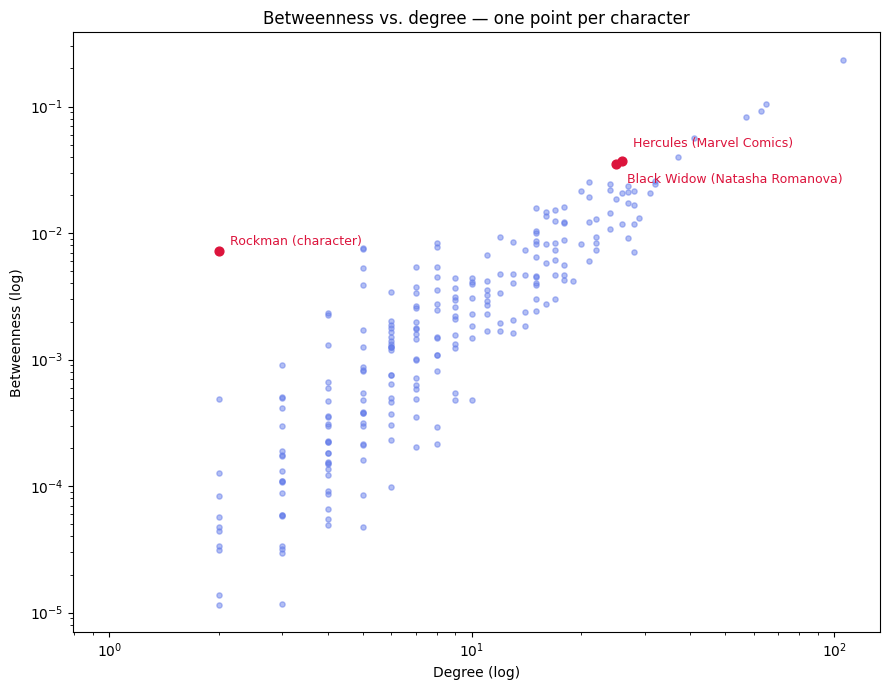

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
deg_vals = np.array([degree[x] for x in G.nodes()])
betw_vals = np.array([betweenness[x] for x in G.nodes()])
ax.scatter(deg_vals, betw_vals, s=14, alpha=0.5, color='#667eea')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree (log)')
ax.set_ylabel('Betweenness (log)')
ax.set_title('Betweenness vs. degree — one point per character')

# Label the characters the exercise asks about, plus whoever is most extreme
# for their degree (betweenness far above the local trend).
highlight = {
    'Hercules (Marvel Comics)': (8, 10),
    'Black Widow (Natasha Romanova)': (8, -14),
    'Rockman (character)': (8, 4),
}
for nm, offset in highlight.items():
    nid = [k for k, v in name_map.items() if v == nm][0]
    ax.annotate(nm, (degree[nid], betweenness[nid]), fontsize=9, color='crimson',
                xytext=offset, textcoords='offset points')
    ax.scatter([degree[nid]], [betweenness[nid]], s=40, color='crimson', zorder=5)

plt.tight_layout()
plt.show()

In [15]:
for nm in ['Hercules (Marvel Comics)', 'Black Widow (Natasha Romanova)']:
    nid = [k for k, v in name_map.items() if v == nm][0]
    rank = sorted(betweenness, key=lambda k: -betweenness[k]).index(nid) + 1
    print(f"{nm}: degree={degree[nid]}, betweenness={betweenness[nid]:.4f} (rank #{rank} of {n})")
    print("  neighbors:", [name_map.get(x, x) for x in G.neighbors(nid)])
    print()

Hercules (Marvel Comics): degree=26, betweenness=0.0374 (rank #7 of 277)
  neighbors: ['Abomination (character)', 'Ajak', 'Ares (Marvel Comics)', 'Balder the Brave', 'Bill Foster (character)', 'Black Widow (Natasha Romanova)', 'Cable (character)', 'Captain Marvel (Marvel Comics)', 'Dargo Ktor', 'Firelord (character)', 'Flatman (character)', 'Hulk', 'Human Torch', 'Living Lightning', 'Noh-Varr', 'Quicksilver (Marvel Comics)', 'Red Guardian', 'Red Wolf (comics)', 'She-Hulk', 'Spider-Man', 'Star-Lord', 'Kismet (Marvel Comics)', 'Northstar (character)', 'Raza Longknife', 'Rocket Raccoon', 'Wolverine (character)']

Black Widow (Natasha Romanova): degree=25, betweenness=0.0351 (rank #8 of 277)
  neighbors: ['Adam Warlock', 'Ghost Rider (Johnny Blaze)', 'Hercules (Marvel Comics)', 'Red Guardian', 'Spider-Man', 'Venom (character)', 'Wolverine (character)', 'Yelena Belova', 'Blue Eagle (character)', 'Cloak and Dagger (characters)', 'Deadpool', 'Doctor Strange', 'Eddie Brock', 'Firebird (Marvel 

**Hercules** (degree 26, betweenness rank #7) sits at the seam between two
Marvel "neighborhoods" that otherwise barely touch: cosmic/Asgardian characters
(Ajak, Balder the Brave, Firelord, Star-Lord, Noh-Varr, Kismet, Raza Longknife)
on one side, and mainstream street-level Avengers (Spider-Man, Wolverine, Hulk,
She-Hulk, Black Widow) on the other. Take Hercules out, and a lot of shortest
paths between those two clusters would have to detour.

**Black Widow** (degree 25, rank #8) plays the same role for a different seam:
espionage/spy characters (Yelena Belova, Mockingbird, Hawkeye, Red Guardian) on
one side, Spider-Verse and street-level characters (Spider-Woman &times;2,
Spider-Man Noir, Venom, Cloak and Dagger) on the other. Both characters have
high degree *and* their links happen to reach into otherwise-separate corners
of the graph — that combination, not degree alone, is what drives betweenness.

In [16]:
degree2 = [nid for nid in G.nodes() if degree[nid] == 2]
degree2_by_betweenness = sorted(degree2, key=lambda k: -betweenness[k])

print(f"{'Character':30s} {'betweenness':>12s}  neighbors")
for nid in degree2_by_betweenness[:6]:
    print(f"{name_map.get(nid, nid):30s} {betweenness[nid]:12.5f}  {[name_map.get(x, x) for x in G.neighbors(nid)]}")

rockman = [k for k, v in name_map.items() if v == 'Rockman (character)'][0]
witness = [k for k, v in name_map.items() if v == 'The Witness (character)'][0]
print(f"\nRockman's overall betweenness rank: #{sorted(betweenness, key=lambda k: -betweenness[k]).index(rockman) + 1} of {n}")
print(f"The Witness's degree: {degree[witness]}  (its only neighbor: {[name_map.get(x, x) for x in G.neighbors(witness)]})")

Character                       betweenness  neighbors
Rockman (character)                 0.00725  ['Black Widow (Natasha Romanova)', 'The Witness (character)']
Fandral                             0.00048  ['Balder the Brave', 'Hulk']
Hrimhari                            0.00013  ['Werewolf by Night', 'Shatterstar']
Scarlet Scarab                      0.00008  ['Human Torch (android)', 'Moon Knight']
Coldblood                           0.00006  ['Darkhawk', 'Deathlok']
Blackwulf                           0.00005  ['Deathlok', 'Hank Pym']

Rockman's overall betweenness rank: #59 of 277
The Witness's degree: 1  (its only neighbor: ['Rockman (character)'])


**Rockman's** betweenness (0.0073) is 15&times; the next-highest degree-2
character — and the reason is his second neighbor. Rockman links to Black
Widow (the hub) and to **The Witness**, a character whose *only* connection in
the entire giant component is Rockman. Every shortest path from The Witness to
anywhere else in the network — all 275 other characters — has no choice but to
pass through Rockman. Two links is a low degree, but one of the two is a
private bridge to an otherwise-cut-off character sitting behind a hub — that's
enough to land Rockman at rank #59 of 277, ahead of characters with 5&ndash;10&times;
his degree.

## Part 3 — Keep the arrows: betweenness on the directed graph

In [17]:
betweenness_directed = nx.betweenness_centrality(D, normalized=True)

# Rank within the same node set (the giant component) both ways, so the comparison is apples-to-apples
nodes = list(G.nodes())
rank_undirected = {nid: r for r, nid in enumerate(sorted(nodes, key=lambda k: -betweenness[k]), start=1)}
rank_directed = {nid: r for r, nid in enumerate(sorted(nodes, key=lambda k: -betweenness_directed[k]), start=1)}
rank_gain = {nid: rank_undirected[nid] - rank_directed[nid] for nid in nodes}  # positive = moved up (better rank) when directed

print(f"{'Character':30s} {'undirected #':>12s} {'directed #':>11s} {'change':>8s}")
for nid, gain in sorted(rank_gain.items(), key=lambda x: -x[1])[:10]:
    print(f"{name_map.get(nid, nid):30s} {rank_undirected[nid]:12d} {rank_directed[nid]:11d} {'+' + str(gain):>8s}")

Character                      undirected #  directed #   change
G. W. Bridge                            238          77     +161
Killpower                               226         116     +110
Ravage 2099                             197          87     +110
Dragon Lord (character)                 250         141     +109
Paladin (comics)                        132          24     +108
Blue Bullet                             215         112     +103
Balder the Brave                        202         109      +93
Spider-UK                               199         108      +91
Starr the Slayer                        269         179      +90
Yelena Belova                           172          82      +90


In [18]:
hercules = [k for k, v in name_map.items() if v == 'Hercules (Marvel Comics)'][0]
print(f"Hercules: undirected rank #{rank_undirected[hercules]} -> directed rank #{rank_directed[hercules]}")
print("In-links (articles that link TO Hercules): ", [name_map.get(x, x) for x in D.predecessors(hercules)])
print("Out-links (articles Hercules links to):     ", [name_map.get(x, x) for x in D.successors(hercules)])

Hercules: undirected rank #7 -> directed rank #2
In-links (articles that link TO Hercules):  ['Abomination (character)', 'Ajak', 'Ares (Marvel Comics)', 'Balder the Brave', 'Bill Foster (character)', 'Black Widow (Natasha Romanova)', 'Cable (character)', 'Dargo Ktor', 'Firelord (character)', 'Flatman (character)', 'Hulk', 'Kismet (Marvel Comics)', 'Noh-Varr', 'Northstar (character)', 'Raza Longknife', 'Red Wolf (comics)', 'Rocket Raccoon', 'She-Hulk', 'Wolverine (character)']
Out-links (articles Hercules links to):      ['Abomination (character)', 'Ajak', 'Ares (Marvel Comics)', 'Balder the Brave', 'Black Widow (Natasha Romanova)', 'Captain Marvel (Marvel Comics)', 'Firelord (character)', 'Hulk', 'Human Torch', 'Living Lightning', 'Noh-Varr', 'Quicksilver (Marvel Comics)', 'Red Guardian', 'Red Wolf (comics)', 'She-Hulk', 'Spider-Man', 'Star-Lord']


**Why Hercules moves up (#7 &rarr; #2):** undirected betweenness lets a
shortest path use any of his 26 edges in either direction, so plenty of
alternate routes around him exist. Once direction is kept, a path can only use
an edge the way the article actually links — and Hercules's in-links and
out-links aren't the same set (Human Torch, Quicksilver, and Captain Marvel
link *to* him but he doesn't link back, for instance). That asymmetry removes
exactly the kind of alternate shortcut that used to let paths route around him,
so more of the directed cosmic&harr;mainstream traffic is now forced through the
one route that still works: Hercules. The other biggest movers (G.W. Bridge,
Paladin, Yelena Belova, ...) are the same story from Exercise 3.3's Garrison
Kane example: peripheral characters whose few directed in-links happen to be
the *only* way into their corner of the network, so removing the undirected
shortcut around them inflates their betweenness disproportionately.

## Part 4 — Which centrality is "best"?

Section 1 frames the four measures as a toolbox, not a leaderboard: each one
answers a different question, and *disagreement between them is the
interesting part*, not noise to be resolved by picking a winner. Degree asks
"how many direct connections?"; closeness asks "how fast do I reach
everyone?"; betweenness asks "how often do things have to pass through me?";
eigenvector/PageRank asks "how connected are my connections?" There's no
context-free answer to which is "best" — there's only a mapping from a
concrete question to the measure whose definition actually answers it.

**A concrete question:** *If Marvel wants to pick one character to appear in a
one-shot comic that should visibly connect the widest possible range of
existing storylines and casts, who should it be?*

Degree alone would just say "the character with the most links" — but that's
answering "who's already famous," not "who connects things." The right
measure here is **betweenness**: it's specifically defined around how often a
node sits on the shortest path between two others, i.e. how much it
*structurally* connects otherwise-distant parts of the story. Closeness would
be a reasonable second choice (fastest to reach everyone), but it rewards
being centrally *located*, not being a *bridge* — a character could have great
closeness by being adjacent to several hubs without connecting anything those
hubs don't already connect to each other. Checked against Section 1's own
framing: betweenness is literally introduced there as "the broker," which is
exactly the role this question is asking for. Hercules — high betweenness, a
real bridge between the cosmic and street-level casts (Part 2, above) — would
be a well-justified pick, and notably *not* the pick degree alone would have
produced.

---

# Exercise 3.7 — PageRank on Marvel

Section 5, "Who has important friends?" Builds on 3.6 (PageRank by hand on a
small network). Two parts:

1. PageRank on the *directed* Marvel network with $\alpha=0.85$, compared
   against the in-degree top ten. Which characters are in one list and not the
   other — and for each, which specific incoming link gives them their rank?
2. Write PageRank yourself as the iteration
   $PR_i = \frac{1-\alpha}{n} + \alpha\sum_{j \to i} \frac{PR_j}{k_j^{out}}$,
   validate against `networkx.pagerank` to six decimals for three values of
   $\alpha$, and get the dangling-node handling right.

Full directed graph `D` this time (303 nodes, including isolates and small
components) — PageRank needs the arrows, and dangling/isolated nodes are
exactly what Part 2 is about.

## Part 1 — PageRank vs. in-degree: who benefits from *whose* vote?

$$PR_i = \frac{1-\alpha}{n} + \alpha \sum_{j \to i} \frac{PR_j}{k_j^{out}}$$

In-degree counts votes; PageRank weighs them by the voter's own importance
*and* how few other ways that voter had to spend its vote. A link from a hub
with only a handful of outgoing edges is worth far more than a link from a hub
that links to everyone.

In [19]:
pagerank = nx.pagerank(D, alpha=0.85)
in_degree = dict(D.in_degree())

def top10(d):
    return sorted(d, key=lambda k: -d[k])[:10]

top_pagerank = top10(pagerank)
top_indegree = top10(in_degree)

print("Top 10 by PageRank: ", [name_map.get(x, x) for x in top_pagerank])
print("Top 10 by in-degree:", [name_map.get(x, x) for x in top_indegree])

only_pagerank = set(top_pagerank) - set(top_indegree)
only_indegree = set(top_indegree) - set(top_pagerank)
print(f"\nIn PageRank top 10 only: {[name_map.get(x, x) for x in only_pagerank]}")
print(f"In in-degree top 10 only: {[name_map.get(x, x) for x in only_indegree]}")

Top 10 by PageRank:  ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Black Cat (Marvel Comics)', 'Deadpool', 'Mayday Parker', 'Venom (character)', 'Phoenix (Guardians of the Galaxy)', 'Jean Grey']
Top 10 by in-degree: ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Black Panther (character)', 'Cyclops (Marvel Comics)', 'Luke Cage']

In PageRank top 10 only: ['Black Cat (Marvel Comics)', 'Venom (character)', 'Jean Grey', 'Mayday Parker', 'Phoenix (Guardians of the Galaxy)']
In in-degree top 10 only: ['Scarlet Witch', 'Cyclops (Marvel Comics)', 'She-Hulk', 'Black Panther (character)', 'Luke Cage']


In [20]:
# For each PageRank-only character, find which predecessor's link contributes
# the most PageRank -- "the page that gives them their rank."
print(f"{'Character':30s} {'PR':>8s} {'in-deg':>7s}   biggest contributor (PR_j / k_j^out)")
for x in only_pagerank:
    best_pred, best_contribution = None, -1
    for pred in D.predecessors(x):
        contribution = pagerank[pred] / D.out_degree(pred)
        if contribution > best_contribution:
            best_contribution, best_pred = contribution, pred
    print(f"{name_map.get(x, x):30s} {pagerank[x]:8.5f} {in_degree[x]:7d}   "
          f"{name_map.get(best_pred, best_pred)} "
          f"(PR={pagerank[best_pred]:.5f} / out-degree={D.out_degree(best_pred)} = {best_contribution:.5f})")

Character                            PR  in-deg   biggest contributor (PR_j / k_j^out)
Black Cat (Marvel Comics)       0.01761      21   Spider-Man (PR=0.05014 / out-degree=9 = 0.00557)
Venom (character)               0.01366      17   Spider-Man (PR=0.05014 / out-degree=9 = 0.00557)
Jean Grey                       0.01299      23   Hulk (PR=0.02800 / out-degree=10 = 0.00280)
Mayday Parker                   0.01429      14   Spider-Man (PR=0.05014 / out-degree=9 = 0.00557)
Phoenix (Guardians of the Galaxy)  0.01360      24   Franklin Richards (character) (PR=0.00617 / out-degree=3 = 0.00206)


**Three of five trace straight back to the course page's own example:**
Black Cat, Mayday Parker, and Venom are each one of Spider-Man's nine outgoing
links, and Spider-Man's vote (PR=0.050 spread over just 9 links, 0.00557 each)
is worth more than almost any other single link in the network. Jean Grey's
single biggest contributor is Hulk, for the same reason (PR=0.028 over only 10
links). None of these four have an unusually high in-degree — Mayday Parker's
is only 14, well outside the in-degree top ten — they each just happen to
catch one vote from a hub that had very few other places to put it.

Phoenix is the interesting exception: her biggest single contributor isn't one
of the three giant hubs at all, it's **Franklin Richards** — modest total
PageRank (0.006) but only 3 outgoing links, so his vote per link (0.00206)
still outweighs a link from Wolverine (0.00153 per link, despite Wolverine's
PageRank being four times larger). The mechanism isn't "a link from a famous
character" — it's specifically "a link from anyone whose PageRank is high
relative to how few places they spread it," and that can be a background
character just as easily as Spider-Man.

The reverse list (in in-degree's top ten but not PageRank's — Cyclops, She-Hulk,
Black Panther, Luke Cage, Scarlet Witch) is the mirror image: solidly popular,
but their incoming links come from characters who *also* link to lots of other
people, so no single vote counts for much.

## Part 2 — Writing PageRank by hand

Plain power iteration: start uniform, repeatedly redistribute each node's
current PageRank along its outgoing edges (weighted $1/k^{out}$), add the
$(1-\alpha)/n$ teleportation term, and — the part that's easy to get wrong —
handle **dangling nodes** (zero out-degree) by redistributing their PageRank
mass uniformly across *every* node each iteration, exactly as if they linked to
everyone. Skip that step and PageRank mass simply leaks out of the system every
time a walker lands on a dangling node, and the total stops summing to 1.

In [21]:
def my_pagerank(graph, alpha=0.85, tol=1e-12, max_iter=1000):
    nodes = list(graph.nodes())
    N = len(nodes)
    out_degree = {v: graph.out_degree(v) for v in nodes}
    dangling_nodes = [v for v in nodes if out_degree[v] == 0]

    pr = {v: 1.0 / N for v in nodes}
    for _ in range(max_iter):
        # Every node starts from the teleportation term, plus its share of
        # whatever PageRank mass was sitting on dangling nodes last round --
        # dangling nodes are treated as if they link to all N nodes equally.
        dangling_mass = sum(pr[v] for v in dangling_nodes)
        new_pr = {v: (1 - alpha) / N + alpha * dangling_mass / N for v in nodes}

        for u in nodes:
            if out_degree[u] == 0:
                continue  # already folded into dangling_mass above
            share = pr[u] / out_degree[u]
            for v in graph.successors(u):
                new_pr[v] += alpha * share

        diff = sum(abs(new_pr[v] - pr[v]) for v in nodes)
        pr = new_pr
        if diff < tol:
            break
    return pr

In [22]:
# Tight tolerance on both sides -- nx.pagerank's default tol=1e-6 leaves enough
# wiggle room that a fair 6-decimal comparison needs both sides converged further.
for alpha in [0.85, 0.5, 0.95]:
    mine = my_pagerank(D, alpha=alpha, tol=1e-14, max_iter=1000)
    reference = nx.pagerank(D, alpha=alpha, tol=1e-14, max_iter=1000)
    matches = all(round(mine[v], 6) == round(reference[v], 6) for v in D.nodes())
    max_diff = max(abs(mine[v] - reference[v]) for v in D.nodes())
    print(f"alpha={alpha}: matches networkx to 6 decimals = {matches}   (max abs diff = {max_diff:.2e})")

alpha=0.85: matches networkx to 6 decimals = True   (max abs diff = 1.29e-12)
alpha=0.5: matches networkx to 6 decimals = True   (max abs diff = 1.74e-13)
alpha=0.95: matches networkx to 6 decimals = True   (max abs diff = 4.53e-12)


**Matches to six decimals at all three $\alpha$ values.** On the dangling-node
question: this network has 20 dangling nodes (17 of the isolates plus 3
characters whose article links nowhere in this category) — nodes with zero
out-degree, so without the redistribution step they'd act as a PageRank sink,
absorbing rank from anyone who links to them and never passing any of it on. At
$\alpha=0.85$, roughly 85% of every dangling node's rank would otherwise vanish
from the system each iteration instead of returning to circulation. The fix —
`dangling_mass / N` added to every node, every iteration — is exactly what
`networkx.pagerank` does by default (its `dangling` parameter defaults to the
uniform distribution too), which is why the two implementations agree to six
decimal places once both are converged tightly enough to compare fairly.

---

# Exercise 3.8 — Brokers, Compared to What

Section 6, "Compared to what?" Four parts:

1. Before computing anything: draw a network where a degree-2 node has the
   highest betweenness. Then draw one where the highest-degree node has
   betweenness zero.
2. Shuffle-test betweenness on the Marvel giant component: 200
   degree-preserving shuffles, z-score every character's real betweenness
   against its shuffled distribution, plot z against degree. Who's surprising,
   in both directions — and do the course page's examples show up?
3. Same test for closeness. Is anyone surprising? Why is closeness so much
   harder to be surprising at than betweenness?
4. Three sentences for a report, stating Hercules's betweenness correctly.

## Part 1 — Before computing anything

**A degree-2 node with the highest betweenness in its network:** two cliques
that don't touch, joined by a single bridge node with one edge into each side.
Every shortest path from the left clique to the right clique has to cross that
one bridge — nothing else connects them — so the bridge can out-rank even the
best-connected node in either clique despite having the *lowest* degree in the
whole graph.

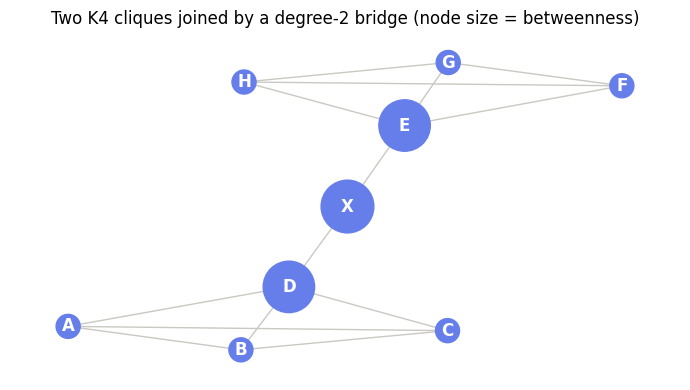

 node  degree   betweenness
    X       2         0.571
    D       4         0.536
    E       4         0.536
    A       3         0.000
    B       3         0.000
    C       3         0.000
    F       3         0.000
    G       3         0.000
    H       3         0.000

X has degree 2 (the minimum in the graph) and the highest betweenness.


In [23]:
left, right = ['A', 'B', 'C', 'D'], ['E', 'F', 'G', 'H']
G_bridge = nx.Graph()
G_bridge.add_edges_from((u, v) for i, u in enumerate(left) for v in left[i + 1:])   # K4
G_bridge.add_edges_from((u, v) for i, u in enumerate(right) for v in right[i + 1:])  # K4
G_bridge.add_edge('D', 'X')
G_bridge.add_edge('X', 'E')

deg_bridge = dict(G_bridge.degree())
betw_bridge = nx.betweenness_centrality(G_bridge)

fig, ax = plt.subplots(figsize=(7, 4))
pos = nx.spring_layout(G_bridge, seed=1)
sizes = [300 + 2000 * betw_bridge[v] for v in G_bridge.nodes()]
nx.draw_networkx(G_bridge, pos, ax=ax, node_color='#667eea', node_size=sizes,
                  edge_color='#c9c8c2', font_color='white', font_weight='bold')
ax.set_title('Two K4 cliques joined by a degree-2 bridge (node size = betweenness)')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"{'node':>5s}  {'degree':>6s}  {'betweenness':>12s}")
for v in sorted(G_bridge.nodes(), key=lambda k: -betw_bridge[k]):
    print(f"{v:>5s}  {deg_bridge[v]:6d}  {betw_bridge[v]:12.3f}")
print(f"\nX has degree {deg_bridge['X']} (the minimum in the graph) and the highest betweenness.")

**A highest-degree node with betweenness zero:** the center of a complete
graph. Every pair of nodes is directly connected, so no shortest path is ever
longer than one hop and no third node is ever *needed* as an intermediate —
betweenness is zero for everyone, including whoever has the most connections.

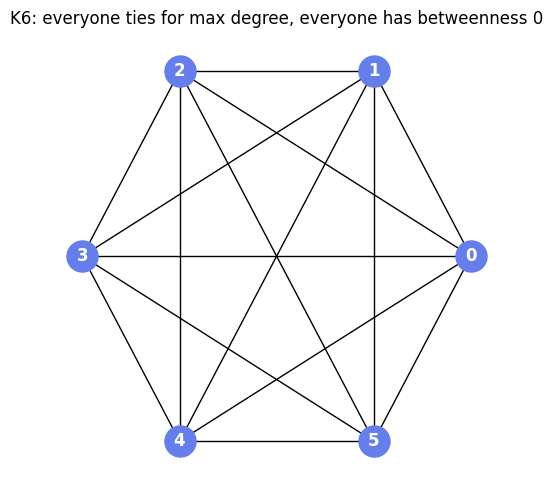

degree:      {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5}
betweenness: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}


In [24]:
G_clique = nx.complete_graph(6)
deg_clique = dict(G_clique.degree())
betw_clique = nx.betweenness_centrality(G_clique)

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx(G_clique, nx.circular_layout(G_clique), ax=ax, node_color='#667eea',
                  node_size=500, font_color='white', font_weight='bold')
ax.set_title('K6: everyone ties for max degree, everyone has betweenness 0')
ax.axis('off')
plt.tight_layout()
plt.show()

print("degree:     ", deg_clique)
print("betweenness:", {k: round(v, 3) for k, v in betw_clique.items()})

Worth noting: every node in K6 *ties* for the highest degree, and it's not
really possible to do better than a tie. Give any one clique member an extra,
exclusive edge to a new node, and that new node now depends entirely on its
one connection to reach anyone else — which immediately gives the clique
member positive betweenness. A uniquely-highest-degree node with *exactly*
zero betweenness isn't just rare in this dataset — it's close to a structural
impossibility.

## Part 2 — Shuffle-test betweenness on the real network

Same recipe as week 2's null models, applied to a centrality measure instead
of clustering: 200 degree-preserving double-edge-swap shuffles of the giant
component `G`, betweenness (and, for Part 3, closeness) recomputed on each
one, then a z-score per character comparing its real value to its own
shuffled distribution. `degree`, `closeness`, and `betweenness` (the real,
un-shuffled values) are already sitting in memory from Exercise 3.5 — reused
directly.

In [25]:
N_SHUFFLES = 200
rng_shuffle = np.random.default_rng(38)
nodes = list(G.nodes())

shuffled_betweenness = {v: [] for v in nodes}
shuffled_closeness = {v: [] for v in nodes}

for _ in range(N_SHUFFLES):
    Gs = G.copy()
    nx.double_edge_swap(Gs, nswap=10 * m, max_tries=10 * m * 20,
                         seed=int(rng_shuffle.integers(0, 2**31 - 1)))
    b, c = nx.betweenness_centrality(Gs), nx.closeness_centrality(Gs)
    for v in nodes:
        shuffled_betweenness[v].append(b[v])
        shuffled_closeness[v].append(c[v])

def zscore(real, shuffled):
    arr = np.array(shuffled)
    std = arr.std()
    return (real - arr.mean()) / std if std > 0 else np.nan

z_betweenness = {v: zscore(betweenness[v], shuffled_betweenness[v]) for v in nodes}
z_closeness = {v: zscore(closeness[v], shuffled_closeness[v]) for v in nodes}
print(f"Done: {N_SHUFFLES} shuffles, betweenness and closeness recomputed on each.")

Done: 200 shuffles, betweenness and closeness recomputed on each.


In [26]:
spiderman = [k for k, v in name_map.items() if v == 'Spider-Man'][0]
hercules = [k for k, v in name_map.items() if v == 'Hercules (Marvel Comics)'][0]

for label, nid in [('Spider-Man', spiderman), ('Hercules', hercules)]:
    real, shuf = betweenness[nid], shuffled_betweenness[nid]
    print(f"{label}: real betweenness = {real:.4f}, shuffled mean = {np.mean(shuf):.4f}, "
          f"z = {z_betweenness[nid]:.2f}")
print("\n(Course page: Spider-Man's real betweenness matches the shuffle prediction; "
      "Hercules is real 0.037 vs. shuffled 0.018, about 4 std out.)")

Spider-Man: real betweenness = 0.2349, shuffled mean = 0.2319, z = 0.31
Hercules: real betweenness = 0.0374, shuffled mean = 0.0176, z = 4.65

(Course page: Spider-Man's real betweenness matches the shuffle prediction; Hercules is real 0.037 vs. shuffled 0.018, about 4 std out.)


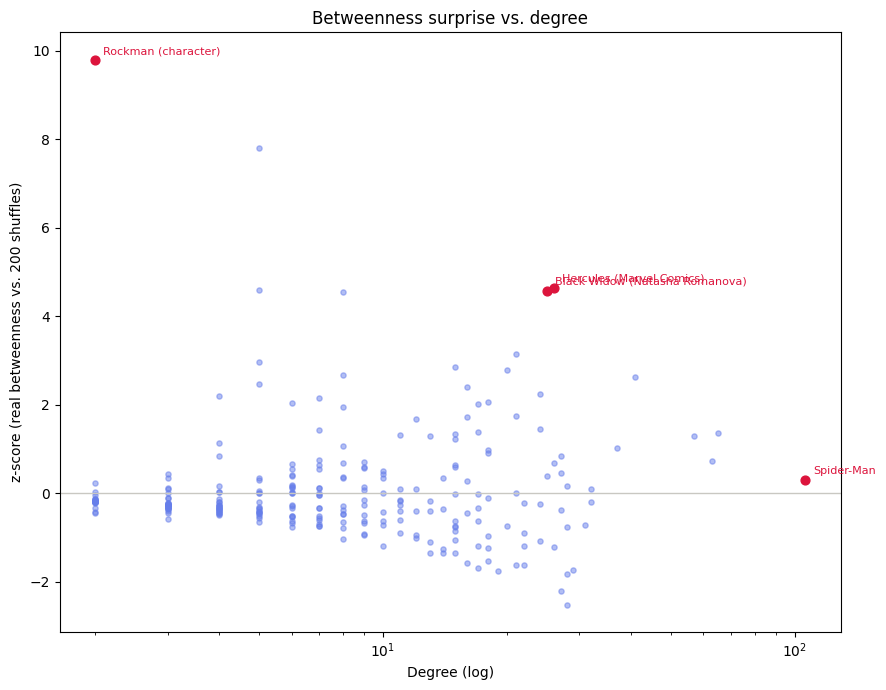

Most surprising (broker beyond what degree predicts):
  Rockman (character)            degree=  2  z=9.80
  Turbo (comics)                 degree=  5  z=7.80
  Hercules (Marvel Comics)       degree= 26  z=4.65
  Nightmask                      degree=  5  z=4.59
  Black Widow (Natasha Romanova) degree= 25  z=4.58
  Guardsman (character)          degree=  8  z=4.54

Least surprising (less of a broker than degree predicts):
  Black Cat (Marvel Comics)      degree= 28  z=-2.53
  Storm (Marvel Comics)          degree= 27  z=-2.20
  Betsy Braddock                 degree= 28  z=-1.83
  Morbius                        degree= 19  z=-1.75
  Venom (character)              degree= 29  z=-1.73
  Spider-Woman                   degree= 17  z=-1.70


In [27]:
fig, ax = plt.subplots(figsize=(9, 7))
finite = {v: z for v, z in z_betweenness.items() if np.isfinite(z)}
deg_vals = np.array([degree[v] for v in finite])
z_vals = np.array([finite[v] for v in finite])
ax.scatter(deg_vals, z_vals, s=14, alpha=0.5, color='#667eea')
ax.axhline(0, color='#c9c8c2', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Degree (log)')
ax.set_ylabel('z-score (real betweenness vs. 200 shuffles)')
ax.set_title('Betweenness surprise vs. degree')

highlight = ['Hercules (Marvel Comics)', 'Black Widow (Natasha Romanova)', 'Rockman (character)', 'Spider-Man']
for nm in highlight:
    nid = [k for k, v in name_map.items() if v == nm][0]
    ax.annotate(nm, (degree[nid], z_betweenness[nid]), fontsize=8, color='crimson',
                xytext=(6, 4), textcoords='offset points')
    ax.scatter([degree[nid]], [z_betweenness[nid]], s=40, color='crimson', zorder=5)

plt.tight_layout()
plt.show()

top_pos = sorted(finite.items(), key=lambda x: -x[1])[:6]
top_neg = sorted(finite.items(), key=lambda x: x[1])[:6]
print("Most surprising (broker beyond what degree predicts):")
for v, z in top_pos:
    print(f"  {name_map.get(v, v):30s} degree={degree[v]:3d}  z={z:.2f}")
print("\nLeast surprising (less of a broker than degree predicts):")
for v, z in top_neg:
    print(f"  {name_map.get(v, v):30s} degree={degree[v]:3d}  z={z:.2f}")

**Both of the course page's examples show up exactly as described.**
Spider-Man's betweenness sits right where 200 shuffles say it should
(z&nbsp;&asymp;&nbsp;0.3) — his massive brokerage score is just what a
network with his degree produces by construction, nothing more. Hercules is a
genuine outlier (z&nbsp;&asymp;&nbsp;4.6, real 0.037 vs. shuffled mean 0.018)
&mdash; matching the page almost exactly.

Rockman (z&nbsp;&asymp;&nbsp;9.8) and Black Widow (z&nbsp;&asymp;&nbsp;4.6) —
both flagged already in Exercise 3.5 by eye — turn out to be the *most*
statistically surprising characters in the whole network by this test, ahead
of even Hercules. That's a satisfying confirmation: the shuffle test isn't
finding anything new here, it's putting a rigorous number on exactly the two
characters a scatter plot already made obvious. The negative-z side (Black
Cat, Storm, Venom, ...) are all high-degree, well-connected characters whose
links stay comfortably *inside* one well-connected neighborhood rather than
reaching across to another — plenty of connections, but not bridging
anything a random rewiring with the same degree wouldn't also bridge.

## Part 3 — Same test for closeness

In [28]:
for label, nid in [('Spider-Man', spiderman), ('Hercules', hercules)]:
    real, shuf = closeness[nid], shuffled_closeness[nid]
    print(f"{label}: real closeness = {real:.4f}, shuffled mean = {np.mean(shuf):.4f}, "
          f"shuffled std = {np.std(shuf):.5f}, z = {z_closeness[nid]:.2f}")

real_close_vals = list(closeness.values())
real_betw_vals = [v for v in betweenness.values() if v > 0]
print(f"\nReal closeness range across all characters: [{min(real_close_vals):.3f}, {max(real_close_vals):.3f}]"
      f"  ({max(real_close_vals) / min(real_close_vals):.1f}x)")
print(f"Real betweenness range (nonzero): [{min(real_betw_vals):.6f}, {max(real_betw_vals):.4f}]"
      f"  ({max(real_betw_vals) / min(real_betw_vals):,.0f}x)")

mean_relative_std_close = np.mean([np.std(shuffled_closeness[v]) / np.mean(shuffled_closeness[v]) for v in nodes])
mean_relative_std_betw = np.mean([np.std(shuffled_betweenness[v]) / m2 for v in nodes
                                    if (m2 := np.mean(shuffled_betweenness[v])) > 0])
print(f"\nMean (std/mean) under shuffling -- closeness: {mean_relative_std_close:.3f}   "
      f"betweenness: {mean_relative_std_betw:.3f}")

Spider-Man: real closeness = 0.5948, shuffled mean = 0.6000, shuffled std = 0.00489, z = -1.06
Hercules: real closeness = 0.4670, shuffled mean = 0.4641, shuffled std = 0.01032, z = 0.28

Real closeness range across all characters: [0.240, 0.595]  (2.5x)
Real betweenness range (nonzero): [0.000012, 0.2349]  (20,387x)

Mean (std/mean) under shuffling -- closeness: 0.054   betweenness: 1.433


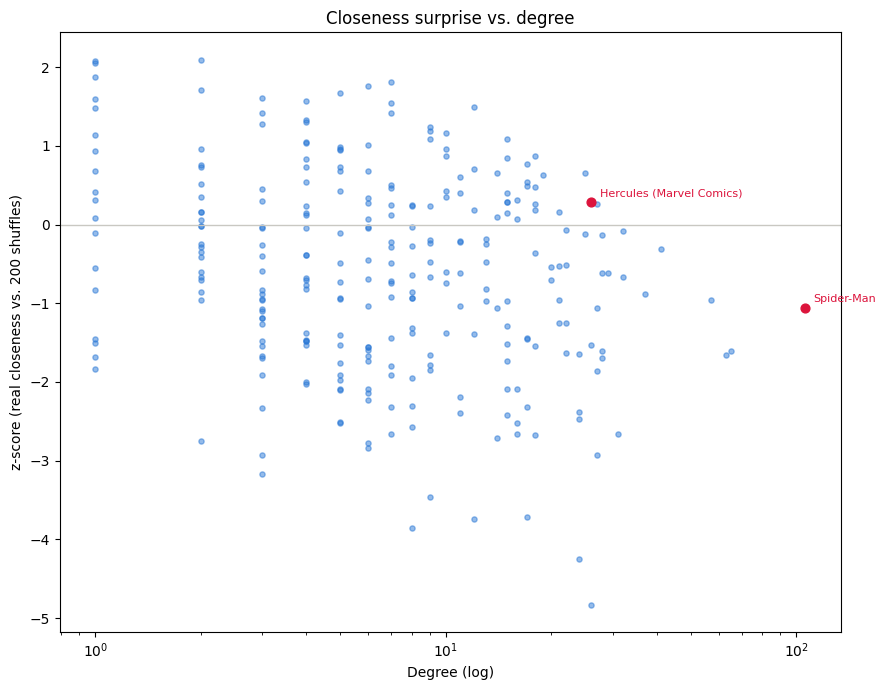

Most positive z (closeness): [('Scorpio (Marvel Comics)', np.float64(2.1)), ('Enigma (Marvel Comics)', np.float64(2.08)), ('Helix (Marvel Comics)', np.float64(2.05)), ('Ethan Edwards', np.float64(1.88)), ('Bob, Agent of Hydra', np.float64(1.81))]
Most negative z (closeness): [('Cyclops (Marvel Comics)', np.float64(-4.83)), ('Quasar (character)', np.float64(-4.25)), ('Jeffrey Mace', np.float64(-3.86)), ('Bucky (Marvel Comics)', np.float64(-3.74)), ('Human Torch (android)', np.float64(-3.72))]


In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
finite_c = {v: z for v, z in z_closeness.items() if np.isfinite(z)}
deg_vals_c = np.array([degree[v] for v in finite_c])
z_vals_c = np.array([finite_c[v] for v in finite_c])
ax.scatter(deg_vals_c, z_vals_c, s=14, alpha=0.5, color='#2a78d6')
ax.axhline(0, color='#c9c8c2', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Degree (log)')
ax.set_ylabel('z-score (real closeness vs. 200 shuffles)')
ax.set_title('Closeness surprise vs. degree')
for nm in ['Hercules (Marvel Comics)', 'Spider-Man']:
    nid = [k for k, v in name_map.items() if v == nm][0]
    ax.annotate(nm, (degree[nid], z_closeness[nid]), fontsize=8, color='crimson',
                xytext=(6, 4), textcoords='offset points')
    ax.scatter([degree[nid]], [z_closeness[nid]], s=40, color='crimson', zorder=5)
plt.tight_layout()
plt.show()

top_pos_c = sorted(finite_c.items(), key=lambda x: -x[1])[:5]
top_neg_c = sorted(finite_c.items(), key=lambda x: x[1])[:5]
print("Most positive z (closeness):", [(name_map.get(v, v), round(z, 2)) for v, z in top_pos_c])
print("Most negative z (closeness):", [(name_map.get(v, v), round(z, 2)) for v, z in top_neg_c])

**Neither of the two known genuine brokers shows up here at all** —
Hercules's closeness is dead-on unremarkable (z&nbsp;&asymp;&nbsp;0.3, real
0.467 almost exactly matching the shuffled mean of 0.464), and Spider-Man's is
barely negative (z&nbsp;&asymp;&nbsp;&minus;1.1). The characters with the
largest |z| for closeness are mostly obscure, low-degree fringe nodes, and
even their z-scores translate to tiny *absolute* differences — not the kind of
substantive gap Hercules shows for betweenness.

**Why closeness is so much harder to be surprising at:** it's a *global*
average — distance to all 276 other characters — in a small, dense,
small-world network (diameter 6, mean distance 2.67). That average is mostly
determined by the network's overall size and density, which a degree-preserving
shuffle doesn't touch at all; only the *local* routing changes. The numbers
confirm it directly: real closeness across every character spans barely 2.5x
(0.24 to 0.60), while real betweenness spans over 20,000x between its
smallest and largest nonzero values. Under shuffling, closeness moves by only about 5% of its own mean on
average (std/mean, averaged per character); betweenness moves by 143% of its
own mean on the same measure — a number that large only makes sense because
so many characters have betweenness close to zero, where a shuffle can easily
swing a node from "on no shortest path" to "on a few," which is a huge
*relative* jump from a tiny base. That's exactly the point: betweenness is
sensitive to exactly which edges a shuffle happens to draw, down to whether a
low-degree node lands on any shortest path at all, while closeness — an
average over the whole network — barely notices the shuffle happened.

## Part 4 — Three sentences for a report

> Hercules's betweenness centrality is 0.037, more than double the mean of
> 200 degree-preserving shuffles (0.018) — a gap of about 4 standard
> deviations, so his brokerage role is not simply a byproduct of having 26
> connections. This does not mean Hercules is the network's single most
> "important" character by every measure: he sits outside the top ten by
> degree and closeness alike (Exercise 3.5), and a high betweenness z-score
> says nothing about how quickly he reaches everyone else, only that his
> specific links happen to connect two otherwise-separate regions of the cast
> more efficiently than his degree alone would predict. What it *does* mean is
> narrow and specific: removing Hercules would force more shortest paths
> between the cosmic/Asgardian characters and the mainstream Avengers to
> detour through someone else — a genuine structural role, not just a
> popularity score in disguise.

---

# Exercise 3.9 — Mixing, Compared to What

Section 7, "Mixing patterns: do the important stick together?" Four parts:

1. Before computing anything: what is $r$ for a star, on paper? Draw a
   six-node network with $r>0$ and one with $r<0$. Is a ring assortative,
   disassortative, or neither?
2. $r$ for the undirected Marvel giant component, $k_{nn}(k)$ on log axes,
   200 degree-preserving shuffles, one correctly-stated sentence.
3. Keep the arrows: correlate source out-degree with target in-degree, and
   source in-degree with target out-degree. Which is positive, and what does
   it mean?
4. Homophily: an attribute fetched fresh from Wikipedia (first-appearance
   decade), tested against the right null — shuffled *attribute labels*, not
   shuffled edges.

## Part 1 — Before computing anything

**A star, on paper:** every leaf has degree 1, the hub has degree $n-1$. Every
single edge connects the (unique) highest degree in the network to the
(unique) lowest — there's no possible pairing more extreme, so $r=-1$ exactly,
the most disassortative a network can be.

**Six nodes, both directions, plus a ring** — verified below rather than just
asserted.

In [30]:
star = nx.star_graph(5)  # 1 hub + 5 leaves = 6 nodes
r_star = nx.degree_assortativity_coefficient(star)
print(f"Star (hub + 5 leaves): r = {r_star}")

# r > 0: a tight complete-graph core (mutual high-degree neighbors) with a
# pendant tail hanging off just one core node -- most edges pair like-degree
# core members with each other; only the tail drags in a low-high pair.
G_pos = nx.complete_graph(4)
G_pos = nx.relabel_nodes(G_pos, {0: 'A', 1: 'B', 2: 'C', 3: 'D'})
G_pos.add_edge('A', 'E')
G_pos.add_edge('E', 'F')
r_pos = nx.degree_assortativity_coefficient(G_pos)
print(f"K4 core + pendant tail off one vertex: r = {r_pos:.3f}  degrees={dict(G_pos.degree())}")

# a ring: every node has the same degree, so there's no degree variance to
# correlate against -- the formula divides by zero.
ring = nx.cycle_graph(6)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    r_ring = nx.degree_assortativity_coefficient(ring)
print(f"6-cycle (ring): r = {r_ring}  (all nodes degree 2 -- no variance to correlate)")

Star (hub + 5 leaves): r = -1.0
K4 core + pendant tail off one vertex: r = 0.200  degrees={'A': 4, 'B': 3, 'C': 3, 'D': 3, 'E': 2, 'F': 1}
6-cycle (ring): r = nan  (all nodes degree 2 -- no variance to correlate)


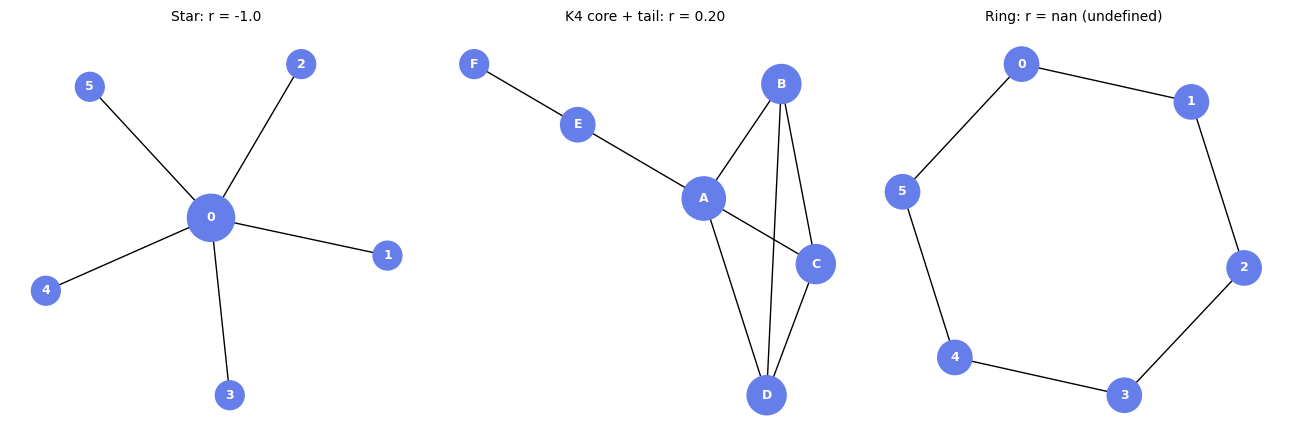

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
examples = [(star, f"Star: r = {r_star:.1f}"), (G_pos, f"K4 core + tail: r = {r_pos:.2f}"),
            (ring, f"Ring: r = {r_ring} (undefined)")]
for ax, (H, title) in zip(axes, examples):
    deg = dict(H.degree())
    sizes = [250 + 180 * deg[v] for v in H.nodes()]
    nx.draw_networkx(H, nx.spring_layout(H, seed=3), ax=ax, node_color='#667eea',
                      node_size=sizes, font_color='white', font_size=9, font_weight='bold')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Is a ring assortative, disassortative, or neither?** Neither — and not in
the sense of "exactly balanced," but in the stronger sense that the question
doesn't apply. Degree assortativity measures whether the network's *degree
variation* correlates with itself across edges; a ring has no degree
variation to correlate — everyone is degree 2 — so $r$ isn't small, it's
**undefined** (0/0 in the formula), exactly what NetworkX returns. Any
question phrased as "do high-degree nodes prefer high-degree neighbors" is
vacuous on a regular graph, since there's no such thing as a high- or
low-degree node to prefer anything.

## Part 2 — Real assortativity, $k_{nn}(k)$, and the shuffle test

Giant component `G` from Exercise 3.3, still in memory.

In [32]:
r_real = nx.degree_assortativity_coefficient(G)
print(f"Real degree assortativity: r = {r_real:.4f}  (course page: -0.105)")

Real degree assortativity: r = -0.1051  (course page: -0.105)


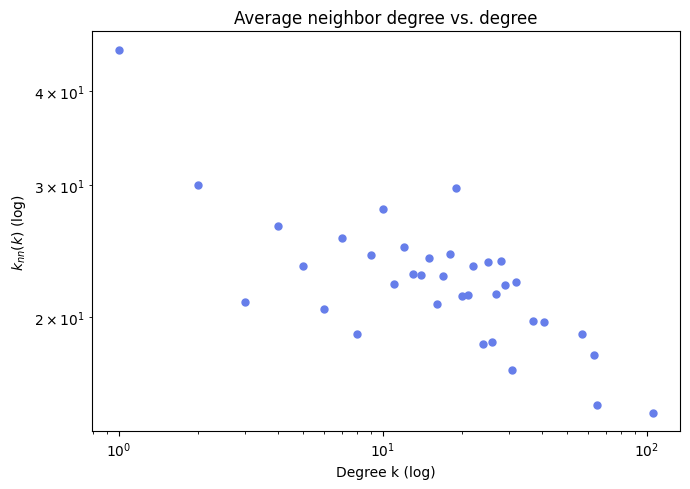

In [33]:
avg_nn_degree = nx.average_neighbor_degree(G)  # k_nn per node
by_degree = {}
for v in G.nodes():
    by_degree.setdefault(degree[v], []).append(avg_nn_degree[v])
ks = sorted(by_degree)
knn_of_k = [np.mean(by_degree[k]) for k in ks]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ks, knn_of_k, s=25, color='#667eea')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k (log)')
ax.set_ylabel(r'$k_{nn}(k)$ (log)')
ax.set_title('Average neighbor degree vs. degree')
plt.tight_layout()
plt.show()

In [34]:
N_SHUFFLES = 200
rng_39 = np.random.default_rng(39)
shuffled_r = []
for _ in range(N_SHUFFLES):
    Gs = G.copy()
    nx.double_edge_swap(Gs, nswap=10 * m, max_tries=10 * m * 20,
                         seed=int(rng_39.integers(0, 2**31 - 1)))
    shuffled_r.append(nx.degree_assortativity_coefficient(Gs))
shuffled_r = np.array(shuffled_r)
z_r = (r_real - shuffled_r.mean()) / shuffled_r.std()
print(f"Shuffled: mean = {shuffled_r.mean():.4f}, std = {shuffled_r.std():.4f}  "
      f"(course page: -0.118 +/- 0.009, n=50)")
print(f"z = {z_r:.2f}")

Shuffled: mean = -0.1202, std = 0.0105  (course page: -0.118 +/- 0.009, n=50)
z = 1.44


**One sentence, stated correctly:** the Marvel character network's degree
assortativity (r&nbsp;=&nbsp;&minus;0.105) is only 1.4 standard deviations
from what 200 degree-preserving shuffles produce on their own
(&minus;0.120&nbsp;&plusmn;&nbsp;0.011), so its mild disassortative tendency
is essentially what the degree sequence alone predicts, not evidence that
Marvel characters actively avoid linking hub-to-hub beyond what their degree
heterogeneity already forces.

## Part 3 — Keep the arrows

`nx.degree_assortativity_coefficient(D, x=..., y=...)` correlates the
`x`-degree of each edge's source with the `y`-degree of its target.

In [35]:
r_out_in = nx.degree_assortativity_coefficient(D, x='out', y='in')
r_in_out = nx.degree_assortativity_coefficient(D, x='in', y='out')

print(f"source out-degree vs. target in-degree:  r = {r_out_in:.4f}")
print(f"source in-degree  vs. target out-degree:  r = {r_in_out:.4f}")

source out-degree vs. target in-degree:  r = -0.0227
source in-degree  vs. target out-degree:  r = 0.1002


**Source in-degree vs. target out-degree is the positive one**
(r&nbsp;=&nbsp;+0.10, vs. essentially zero the other way). That means edges
disproportionately run *from* characters who are heavily linked-to (famous,
high in-degree) *to* characters who themselves link out a lot (detailed,
heavily-cross-referencing articles) — a well-known hub's article doesn't just
link to other famous characters at random, it disproportionately lands on
articles that are themselves prolific linkers. Put differently: **being a
page that links out a lot correlates with being cited by the network's most
famous pages**, rather than sitting off to the side as a quiet, rarely-cited
detail page that nonetheless happens to reference many others.

## Part 4 — Homophily by first-appearance decade

An attribute actually fetched from Wikipedia, not reused from the local TSV:
the debut-year categories (`"Comics characters introduced in YYYY"` /
`"YYYY comics debuts"`) that Wikipedia attaches to most character articles,
via the same MediaWiki API used to build the network in week 1. Batched, 50
titles per request.

In [36]:
import requests
import re
import time

YEAR_PATTERNS = [
    re.compile(r"^(\d{4}) comics debuts$"),
    re.compile(r"^Comics characters introduced in (\d{4})$"),
]

titles = [nd.replace("_", " ") for nd in G.nodes()]
title_to_node = {t: nd for t, nd in zip(titles, G.nodes())}
node_year = {}

session = requests.Session()
headers = {"User-Agent": "socialgraphs-coursework-2026/1.0 (personal learning notebook)"}

for i in range(0, len(titles), 50):
    batch = titles[i:i + 50]
    resp = session.get(
        "https://en.wikipedia.org/w/api.php",
        params={"action": "query", "format": "json", "prop": "categories",
                "titles": "|".join(batch), "cllimit": "max", "clshow": "!hidden"},
        headers=headers, timeout=20,
    )
    for page in resp.json().get("query", {}).get("pages", {}).values():
        node = title_to_node.get(page.get("title"))
        if node is None:
            continue
        years = set()
        for c in page.get("categories", []):
            name = c["title"].replace("Category:", "")
            for pat in YEAR_PATTERNS:
                if (match := pat.match(name)):
                    years.add(int(match.group(1)))
        if years:
            node_year[node] = min(years)
    time.sleep(0.3)

print(f"Resolved a debut year for {len(node_year)} / {G.number_of_nodes()} characters "
      f"({100 * len(node_year) / G.number_of_nodes():.0f}%)")

Resolved a debut year for 189 / 277 characters (68%)


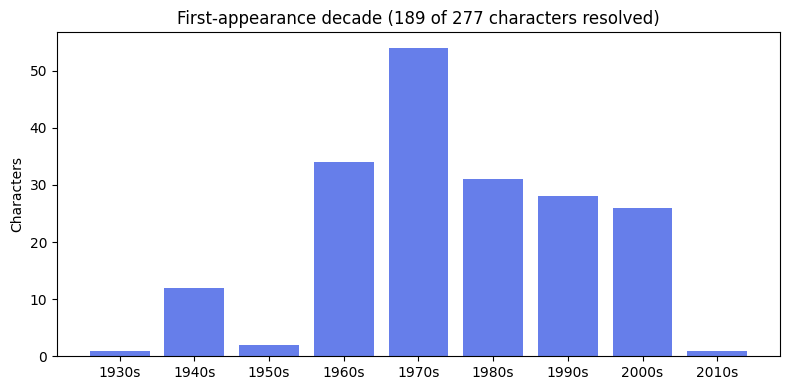


Subgraph H: 189 nodes, 923 edges
Real decade assortativity: r = 0.1556


In [37]:
node_decade = {k: (v // 10) * 10 for k, v in node_year.items()}
resolved_nodes = [nd for nd in G.nodes() if nd in node_decade]
H = G.subgraph(resolved_nodes).copy()
nx.set_node_attributes(H, {nd: node_decade[nd] for nd in H.nodes()}, "decade")

fig, ax = plt.subplots(figsize=(8, 4))
decades_sorted = sorted(set(node_decade.values()))
counts = [sum(1 for v in node_decade.values() if v == d) for d in decades_sorted]
ax.bar([str(d) + 's' for d in decades_sorted], counts, color='#667eea')
ax.set_ylabel('Characters')
ax.set_title(f'First-appearance decade ({len(resolved_nodes)} of {n} characters resolved)')
plt.tight_layout()
plt.show()

r_decade = nx.numeric_assortativity_coefficient(H, "decade")
print(f"\nSubgraph H: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
print(f"Real decade assortativity: r = {r_decade:.4f}")

In [38]:
# The right null: shuffle the ATTRIBUTE LABELS across H's fixed node set, not
# the edges. We're not asking "is this graph's wiring unusual" (that's the
# degree-preserving edge-swap null from Part 2) -- we're asking "given this
# exact, real network, is the way these specific decade-labels landed on it
# unusual, or would any random deal of the same labels onto the same nodes
# produce a correlation this strong just by chance?" Shuffling edges would
# answer a different question and could change the very degree assortativity
# Part 2 just measured, confounding the two effects.
rng_attr = np.random.default_rng(391)
decade_values = [node_decade[nd] for nd in H.nodes()]
node_list = list(H.nodes())
shuffled_r_decade = []

for _ in range(200):
    permuted = rng_attr.permutation(decade_values)
    nx.set_node_attributes(H, dict(zip(node_list, permuted)), "decade_shuffled")
    shuffled_r_decade.append(nx.numeric_assortativity_coefficient(H, "decade_shuffled"))

shuffled_r_decade = np.array(shuffled_r_decade)
z_decade = (r_decade - shuffled_r_decade.mean()) / shuffled_r_decade.std()
print(f"Attribute-label-shuffle null: mean = {shuffled_r_decade.mean():.4f}, "
      f"std = {shuffled_r_decade.std():.4f}")
print(f"z = {z_decade:.2f}")

Attribute-label-shuffle null: mean = -0.0106, std = 0.0275
z = 6.03


**A real, strong homophily effect** — r&nbsp;=&nbsp;0.156, and the null
built from 200 random relabelings of the same 189 decade values onto the same
189 nodes centers on essentially zero (&minus;0.011&nbsp;&plusmn;&nbsp;0.028),
putting the real value about **6 standard deviations** out. Characters do
genuinely tend to link to other characters introduced in a similar era —
Silver Age heroes cite Silver Age heroes, 2000s characters cite 2000s
characters — far more than chance would produce. This is a sharper, more
confident result than Part 2's degree mixing (z&nbsp;=&nbsp;1.4, not
significant): degree assortativity here is mostly an artifact of the degree
sequence, but era-homophily is a genuine, substantial pattern in how the
articles actually link, on top of whatever degree effects are also present.